**Group 4**: Leen Alnajjar, Suyeon Choi, Taebin Sung, Yaroslav Yaldin

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

# Problem Statement

Construct a mathematical model of total annual income for the two locations of Loafe Café where daily average temperature, daily precipitation, and daily humidity affects the income and the total frequency of customers in the month of January $2025$ and the month of July $2025$.

# Variables and Parameters

| Description | Symbol | Dimension | Type |
| :---: | :---: | :---: | :---: |
| Total daily customers | $C$ | 1 | Random Variable |
| Average daily temperature ($^\circ\text{C}$) | $T$ |  $\Theta$ | Random Variable |
| Total daily precipitation ($\text{mm}$) | $P$ |  L | Random Variable |
| Average daily humidity ($\%$) | $H$ | 1 | Random Variable |
| Reference number of customers | $C_0$ | 1 | Parameter |
| Reference temperature ($^\circ\text{C}$) | $T_0$ |  $\Theta$ | Parameter |
| Reference precipitation ($\text{mm}$) | $P_0$ |  L | Parameter |
| Reference humidity ($\%$) |  $H_0$ | 1 | Parameter |
| Temperature sensitivity | $a$ | $\Theta^{-2}$ | Parameter |
| Precipitation sensitivity | $b$ | L$^{-1}$ | Parameter |
| Humidity sensitivity | $c$ | 1 | Parameter |
| Average spending per customer (CAD) | $\bar M$ | $\$$ | Parameter |
| Total daily income (CAD) | $M$ | $\$$ | Random Variable |
| Total annual income (CAD) | $M_{\text{year}}$ | $\$$ | Random Variable |

# Assumptions and Constraints

- The total number of daily customers is the sum over both locations (Alumni and Sauder) and modelled by one function $C(T,P,H)$.
- Any other factors (i.e., locations of two cafés, student populations) besides weather have a negligible effect on the number of daily customers.
- Menu prices are fixed throughout the year and tips are not included in the income.
- The weather measurements are representative of UBC.
- The weather measurements from $1997$ to $2024$ also represent weather data in $2025$.
- All customers on a given day experience the same daily mean of $T,P,$ and $H$.
- Each day's weather is independent of the previous day.
- The weather condition variables $T,P,$ and $H$ are approximated by Gaussian KDEs.
- For each simulated year and month $m$, days are sampled independently from these KDEs.
- The customer parameters $(C_0,T_0,P_0,H_0,a,b,c, \bar M)$ are constant throughout the year.
- We treat 2025 as a 365-day (non-leap) year.

# Building Solutions

## Model Equations
The total annual income is:
$$M_{\text{year}} = \sum\limits_{t=1}^{365} M_t,$$ 
where 
$$M_t = \bar M \cdot C, \qquad C = \text{max}\{c(T,P,H), 0\}, \qquad c(T,P,H) = C_0 + a(T - T_0)^2 - b(P - P_0) - c(H - H_0)^2.$$

In [2]:
weather = pd.read_csv("weatherstats_vancouver_daily_2025.csv") # Import data sets
customer = pd.read_csv("customer_data_2025.csv")

jan_total_cust = (customer["January_Frequency_Customers_Alumni_Centre"] + customer["January_Frequency_Customers_Sauder"]).sum() # Extract total customer in Jan
jul_total_cust = (customer["July_Frequency_Customers_Alumni_Centre"] + customer["July_Frequency_Customers_Sauder"]).sum() # Extract total customer in July
month_days = {1:31, 2:28, 3:31, 4:30, 5:31, 6:30, 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}

def monthly_kde(df, col): # return kde for every month with a given weather type
    return {m: stats.gaussian_kde(df.loc[df["Month"] == m, col].values) for m in range(1,13)}

kde_T, kde_P, kde_H = monthly_kde(weather, "temperature"), monthly_kde(weather, "precipitation"), monthly_kde(weather, "humidity")

## Parameter Choice

We set $T_0 = 25^\circ\text{C}$ as the preferred indoor temperatures are $20\text{-}24^\circ\text{C}$ [Fanger, P. O., 1970; de Dear, R., 2017; ASHRAE, 2017]. Coastal Vancouver humidity of $70\text{-}90\%$ and indoor comfort guidelines $\lesssim 60\%$ relative humidity (RH) suggest that $H_0 = 85\%$ [Fanger, P. O., 1970; Parsons, K., 2014; ASHRAE, 2017]. Typical dry days have $P \approx 0 \text{ mm}$ and rainfall reduces each trip by about $10\text{-}30\%$ [de Freitas, C. R., 2003; Koetse, M. J., 2009], so we set $P_0 = 0 \text{ mm}$.

In [3]:
C0, T0, P0, H0, a, b, c = 280.0, 20.0, 0.0, 85.0, 0.50, 5.00, 0.50      # Reference values

def C_hat(T,P,H): # given customer model
    return np.maximum(C0 + a*(T-T0)**2 - b*(P-P0) - c*(H-H0)**2, 0.0)

def month_expectation(m, n=100_000): # Monte Carlo expectation for a given month
    Tm, Pm, Hm = kde_T[m].resample(n), kde_P[m].resample(n), kde_H[m].resample(n)
    return month_days[m] * np.mean(C_hat(Tm,Pm,Hm))

expected_jan_cust, expected_jul_cust = month_expectation(1), month_expectation(7)

print(f"January 2025 (observed vs model): observed = {jan_total_cust:,.0f} | expected = {expected_jan_cust:,.0f}")
print(f"July 2025 (observed vs model): observed = {jul_total_cust:,.0f} | expected = {expected_jul_cust:,.0f}")

January 2025 (observed vs model): observed = 10,862 | expected = 10,684
July 2025 (observed vs model): observed = 5,438 | expected = 5,239


January and July $2025$ total customer frequencies ($10,862$ and $5,438$ customers, respectively) imply mean daily volume of about $350$ and $175$, so we set $C_0 = 280$ and sensitivities $a = 0.5, b = 5, c = 0.5$. This makes a $10^\circ\text{C}$, $10 \text{ mm}$, or $10\%$ RH change shift demand by approximately $50$ customers ($\approx 15\text{-}25\%$ of $C_0$), which is consistent with reported weather effects [de Freitas, C. R., 2003; Koetse, M. J., 2009]. We verify that these parameters reproduce the Janaury and July $2025$ totals to within a few percent using Monte Carlo simulations based on month-wise KDE weather distributions.

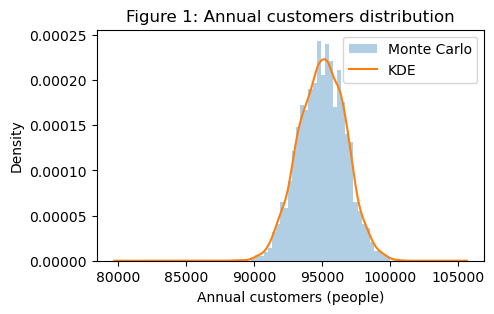

Annual customers (Monte Carlo): Mean = 94,998 | Median = 95,040 | 95% CI = [91,664,98,255]


In [4]:
# Annual Monte Carlo for total customers
N_years = 3000
annual_customers = np.zeros(N_years)

for month in range(1,13):
    days = month_days[month]
    Tm, Pm, Hm = kde_T[month].resample(days*N_years), kde_P[month].resample(days*N_years), kde_H[month].resample(days*N_years)
    annual_customers += C_hat(Tm, Pm, Hm).reshape(N_years, days).sum(axis=1)

C_mean = np.mean(annual_customers)
C_med = np.median(annual_customers)
C_lo, C_hi = np.quantile(annual_customers, [0.025,0.975])

x = np.linspace(max(0, annual_customers.min()*0.9), annual_customers.max()*1.05, 400)
plt.figure(figsize=(5,3))
plt.hist(annual_customers, bins=40, density=True, alpha=0.35, label="Monte Carlo")
plt.plot(x, stats.gaussian_kde(annual_customers)(x), label="KDE")
plt.xlabel("Annual customers (people)"), plt.ylabel("Density")
plt.title("Figure 1: Annual customers distribution")
plt.legend(), plt.show()

print(f"Annual customers (Monte Carlo): Mean = {C_mean:,.0f} | Median = {C_med:,.0f} | 95% CI = [{C_lo:,.0f},{C_hi:,.0f}]")

## Annual Income Scenarios
Google Maps reports a typical spending range of $\$10\text{-}20$ per customer at both locations of Loafe Café [Google Maps, 2025]. Based on this, we consider three fixed average spending values $\bar M \in \{\$10.00, \$15.00, \$20.00 \}$.

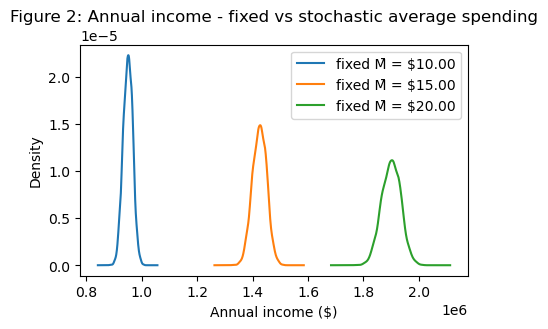

Annual income summary by fixed-spend scenario:
M̄= $10.00: mean = $949,985, 95% CI = [$916,637, $982,552]
M̄= $15.00: mean = $1,424,977, 95% CI = [$1,374,955, $1,473,828]
M̄= $20.00: mean = $1,899,970, 95% CI = [$1,833,274, $1,965,104]


In [5]:
spend_scenarios = [10.00, 15.00, 20.00]

plt.figure(figsize=(5,3))
for mbar in spend_scenarios:
    annual_income_fixed = mbar*annual_customers
    kde_inc = stats.gaussian_kde(annual_income_fixed)
    x_fix = np.linspace(annual_income_fixed.min()*0.95, annual_income_fixed.max()*1.05, 400)
    plt.plot(x_fix, kde_inc(x_fix), label=f"fixed M\u0304 = ${mbar:.2f}")

plt.xlabel("Annual income ($)"),plt.ylabel("Density")
plt.title("Figure 2: Annual income - fixed vs stochastic average spending")
plt.legend(), plt.show()

print("Annual income summary by fixed-spend scenario:")

for mbar in spend_scenarios:
    annual_income_fixed = mbar * annual_customers
    mu = np.mean(annual_income_fixed)
    lo, hi = np.quantile(annual_income_fixed, [0.025, 0.975])
    print(f"M\u0304= ${mbar:>4.2f}: mean = ${mu:,.0f}, 95% CI = [${lo:,.0f}, ${hi:,.0f}]")

# Analyze and Assess

## Observations and Analysis

We sampled the annual total customers through Monte Carlo. This is represented by the blue histogram in the figure above. We simulated $3000$ possible years taking into account the weather conditions and calculated customer count per day accordingly. Then we summed them across the days to get the annual total customer count. We also fitted the KDE to estimate the distribution of the annual customers.	

Overall, our plot is shaped like a bell curve since some simulated years would have ‘better’ weather ($T, P, H$ that deviate less from reference values) therefore more customers, and some simulated years had ‘worse’/less ideal weather so they have fewer customers. Due to the central limit theorem, the total tends to approximately take the shape of a normal distribution, with a mean of about $94,998$ customers per year. Having a normal distribution suggests that, in our model, Loafe Café has a relatively stable annual customer volume when random fluctuations in weather conditions are taken into account. We can see that the data mostly lies between $90,000$ and $100,000$ customers and that the peak of the histogram is at around $95,000$ customers per year which means it is the most likely outcome, the width shows the uncertainty due to weather randomness (Figure 1).

After multiplying (scaling) our annual customer distribution by $\bar M$ (average spending per customer), we obtain a uni-modal (approximately normal) distribution (Figure 2). Each curve represents a different $\bar M$ value. The shape and spread are pretty similar across different average spending amounts which tells us that the weather affects customers in similar ways.

## Model Limitations

We assumed that all other factors besides weather have a negligible effect on the number of daily customers to simplify our model. Realistically, there are many other parameters affecting the number of customers. For example, the customer counts in January and July would vary as there is a larger number of students on campus at the beginning of the winter session as opposed to July, which is during the summer session. Including variables like the number of students on campus (taking into consideration the time in the semester and exam seasons) would strengthen our model and help us make more accurate predictions about the income. The income per day could also vary with promotions and popularity of seasonal drinks; including this in our model could account for that variability.

Usually, businesses do not have fixed menu prices in the long run. Prices can be affected by the demand for their product, competition, and supply constraints, assuming fixed menu prices in turn assume a very simple economic model that can be improved by considering economic factors. 

Our assumption that the weather data from $1997$ to $2024$ is representative of weather data in $2025$ can also be improved by either collecting or generating $2025$ weather data, assuming historical data is representative disregards weather trends such as global warming and climate change.

Assuming that the average daily spending per customer is fixed also limits our model, as we do not account for variables such as different types of customers (students/staff/other) and different income levels.


# Bibliography

[1] ASHRAE. *Thermal Environmental Conditions for Human Occupancy*. ASHRAE, Atlanta, (2017)

[2] de Dear, R., & Brager, G. S., *Developing an adaptive model of thermal comfort and preference*. ASHRAE Trans., 104(1), (1998).

[3] de Freitas, C. R. *Tourism climatology: evaluating environmental information for decision making and business planning in the recreation and tourism sector*. Int J Biometeorol, 48, (2003).

[4] Fanger, P. O. *Thermal comfort: Analaysis and applications in environmental engineering*. Danish Technical Press, Copenhagen, (1970).

[5] Google Maps. *Loafe Café - Alumni Centre UBC - Google Maps*. Google LLC, (2025). [https://www.google.com/maps/place/Loafe_Café+-Alumni+Centre+UBC](https://www.google.com/maps/place/Loafe+Café+-+Alumni+Centre+UBC/@49.2658185,-123.2525216,18z/data=!4m10!1m2!2m1!1sloafe+cafe!3m6!1s0x548672b64ec00ca7:0x6d561b0ad6a3f6f7!8m2!3d49.2658185!4d-123.2501398!15sCgpsb2FmZSBjYWZlIgOIAQFaDCIKbG9hZmUgY2FmZZIBBGNhZmWqAVAKDS9nLzExYndwemR5NnQKDS9nLzExajB4bWpsNGYQATIeEAEiGsX2MgQdzoQmRA85FIM1YaAJ2zIFs_MMjh4LMg4QAiIKbG9hZmUgY2FmZeABAA!16s%2Fg%2F11bwpzdy6t?entry=ttu&g_ep=EgoyMDI1MTExMS4wIKXMDSoASAFQAw%3D%3D)

[6] Koetse, M. J., Rietveld, P. *The impact of climate change and weather on transport: An overview of empirical findings*. Transportation Research Part D: Transport and Environment, 14(3), (2009).

[7] Parsons, K. *Human Thermal Environments: The Effects of Hot, Moderate, and Cold Environments on Human Health, Comfort, and Performance*. CRC Press, Boca Raton, (2014).